<a href="https://colab.research.google.com/github/Hiero-o/checkpoint_02_tritiack/blob/main/cp_02_tritiackipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício de Regressão — Radiação Solar em Petrolina (PE)

## Objetivo

Estimar a radiação solar horizontal média por hora em Petrolina PE a partir das condições meteorológicas e da hora local.

- dados históricos do Open-Meteo;
- período de 01/04/2025 a 30/06/2025;
- somente horários entre 7h e 17h;
- divisão temporal de aproximadamente 80% para treino e 20% para teste;
- sem embaralhar os registros;
- três algoritmos de regressão;
- comparação por MAE, MSE e R
- visualizações e interpretação dos resultados.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

## 1. Consulta à API Open-Meteo

As coordenadas, o período e as variáveis abaixo são os mesmos definidos no enunciado.

In [3]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"

parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "wind_speed_10m",
        "shortwave_radiation"
    ]),
}

resposta_meteo = consultar_api(URL_METEO, parametros_meteo)

if "hourly" not in resposta_meteo:
    raise ValueError("A resposta da API não contém a seção 'hourly'.")

horas_api = resposta_meteo["hourly"]

print("Campos recebidos:")
print(list(horas_api))
print("\nUnidades:")
print(resposta_meteo.get("hourly_units", {}))
print("\nQuantidade total de horários:", len(horas_api["time"]))

Campos recebidos:
['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']

Unidades:
{'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}

Quantidade total de horários: 2184


## 2. Preparação dos dados

As listas retornadas pela API são alinhadas pelo índice. Mantemos apenas registros entre 7h e 17h e removemos linhas com valores ausentes.

A variável-alvo é radiacao_w_m2. Ela não será utilizada como entrada.

In [4]:
nomes_api = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation"
]

linhas_regressao = []

for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]

    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([
            data_hora,
            *valores[:4],
            hora,
            valores[4]
        ])

if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos. Confira a resposta do Open-Meteo.")

dados = pd.DataFrame(
    linhas_regressao,
    columns=[
        "data_hora",
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora",
        "radiacao_w_m2"
    ]
)

dados["data_hora"] = pd.to_datetime(dados["data_hora"])
dados = dados.sort_values("data_hora").reset_index(drop=True)

print("Quantidade de registros válidos:", len(dados))
dados.head()

Quantidade de registros válidos: 1001


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


In [5]:
# Salva o CSV para permitir a reprodução da atividade.
dados.to_csv(
    "meteo_regressao_orange.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV salvo como: meteo_regressao_orange.csv")

CSV salvo como: meteo_regressao_orange.csv


## 3. Análise inicial

As cinco entradas serão:

- `temperatura_c`
- `umidade_pct`
- `nuvens_pct`
- `vento_kmh`
- `hora`

O alvo será:

- `radiacao_w_m2`

A coluna `data_hora` é usada para manter a ordem temporal e não entra diretamente no modelo.

In [6]:
print("Informações do conjunto:")
dados.info()

print("\nValores ausntes:")
print(dados.isna().sum())

print("\nestatísticas descritivas:")
display(dados.describe())

print("\nPrimeiras linhas:")
display(dados.head(10))

Informações do conjunto:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB

Valores ausntes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

estatísticas descritivas:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950



Primeiras linhas:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0
5,2025-04-01 12:00:00,34.2,31,36,19.2,12,905.0
6,2025-04-01 13:00:00,35.0,30,50,19.5,13,910.0
7,2025-04-01 14:00:00,35.0,30,19,17.1,14,733.0
8,2025-04-01 15:00:00,35.3,30,30,17.3,15,699.0
9,2025-04-01 16:00:00,35.0,30,18,17.6,16,443.0


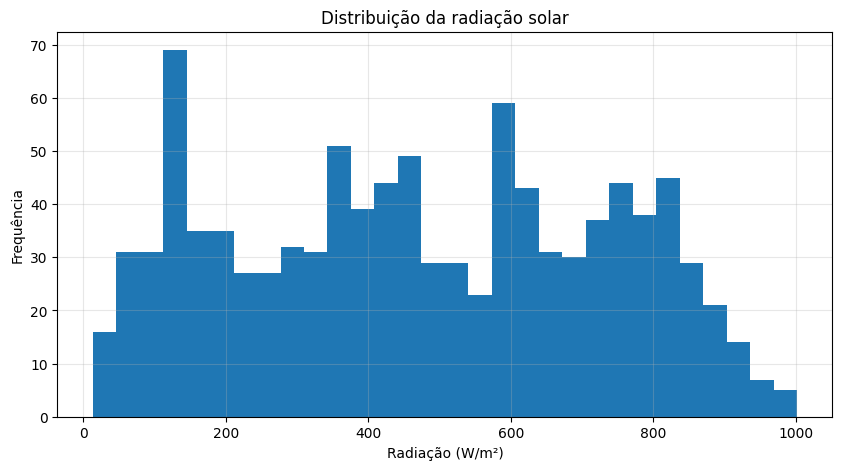

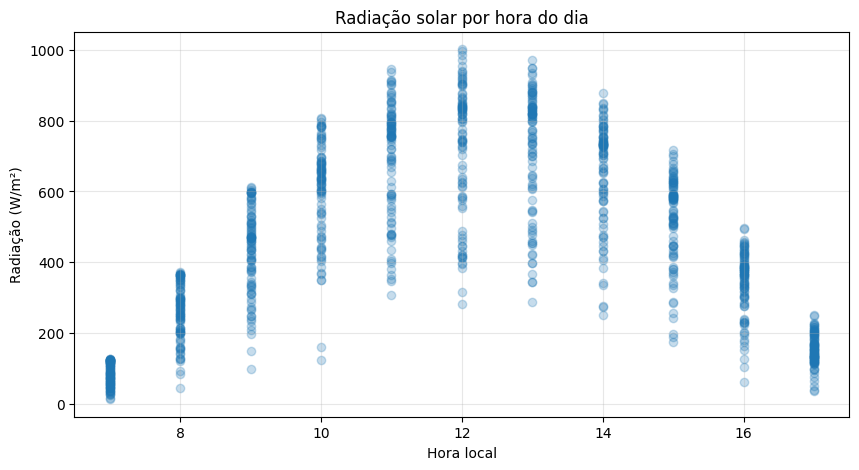

In [7]:
# Distribuição da radiação solar
plt.figure(figsize=(10, 5))
plt.hist(dados["radiacao_w_m2"], bins=30)
plt.title("Distribuição da radiação solar")
plt.xlabel("Radiação (W/m²)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

# Relação entre hora e radiação
plt.figure(figsize=(10, 5))
plt.scatter(dados["hora"], dados["radiacao_w_m2"], alpha=0.25)
plt.title("Radiação solar por hora do dia")
plt.xlabel("Hora local")
plt.ylabel("Radiação (W/m²)")
plt.grid(alpha=0.3)
plt.show()

## 4. Separação temporal entre treino e teste

Como os dados são horários e possuem ordem temporal, não devemos embaralhá-los.

Usaremos:

- **80% das primeiras observações** → treino;
- **20% das últimas observações** → teste.

Essa abordagem simula uma situação em que o modelo aprende com dados anteriores e depois é avaliado em dados posteriores.

In [8]:
features = [
    "temperatura_c",
    "umidade_pct",
    "nuvens_pct",
    "vento_kmh",
    "hora"
]

alvo = "radiacao_w_m2"

X = dados[features].copy()
y = dados[alvo].copy()

corte = int(len(dados) * 0.80)

X_treino = X.iloc[:corte].copy()
X_teste = X.iloc[corte:].copy()

y_treino = y.iloc[:corte].copy()
y_teste = y.iloc[corte:].copy()

print(f"Total de registros: {len(dados)}")
print(f"Treino: {len(X_treino)} ({len(X_treino)/len(dados):.1%})")
print(f"Teste:  {len(X_teste)} ({len(X_teste)/len(dados):.1%})")
print(f"Última data/hora do treino: {dados['data_hora'].iloc[corte-1]}")
print(f"Primeira data/hora do teste: {dados['data_hora'].iloc[corte]}")

Total de registros: 1001
Treino: 800 (79.9%)
Teste:  201 (20.1%)
Última data/hora do treino: 2025-06-12 14:00:00
Primeira data/hora do teste: 2025-06-12 15:00:00


## 5. Treinamento dos três modelos

Serão comparados:

1. Regressão Linear — modelo simples e interpretável, adequado como baseline;
2. Árvore de Decisão — consegue representar relações não lineares;
3. Random Forest — conjunto de várias árvores, geralmente mais robusto a relações complexas.

Todos recebem exatamente a mesma divisão treino/teste.

In [9]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
}

resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)

    previsoes[nome] = y_pred

    mae = mean_absolute_error(y_teste, y_pred)
    mse = mean_squared_error(y_teste, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_teste, y_pred)

    resultados.append({
        "Modelo": nome,
        "MAE (W/m²)": mae,
        "MSE ((W/m²)²)": mse,
        "RMSE (W/m²)": rmse,
        "R²": r2
    })

comparacao = pd.DataFrame(resultados).sort_values(
    "MAE (W/m²)"
).reset_index(drop=True)

comparacao

,Modelo,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
0,Random Forest,66.648526,7332.521161,85.630142,0.843713
1,Árvore de Decisão,86.346625,13610.734567,116.665053,0.709898
2,Regressão Linear,145.204885,30034.201092,173.303783,0.359845


## 6. Comparação dos modelos

MAE representa o erro absoluto médio em W/m². Quanto menor melhor.

MSE penaliza mais fortemente erros grandes. Quanto menor melhor.

R² indica quanto da variação do alvo é explicada pelo modelo. Valores mais próximos de 1 indicam maior capacidade explicativa no conjunto de teste.

In [10]:
display(comparacao.style.format({
    "MAE (W/m²)": "{:.2f}",
    "MSE ((W/m²)²)": "{:.2f}",
    "RMSE (W/m²)": "{:.2f}",
    "R²": "{:.4f}"
}))

,Modelo,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
0,Random Forest,66.65,7332.52,85.63,0.8437
1,Árvore de Decisão,86.35,13610.73,116.67,0.7099
2,Regressão Linear,145.20,30034.20,173.30,0.3598


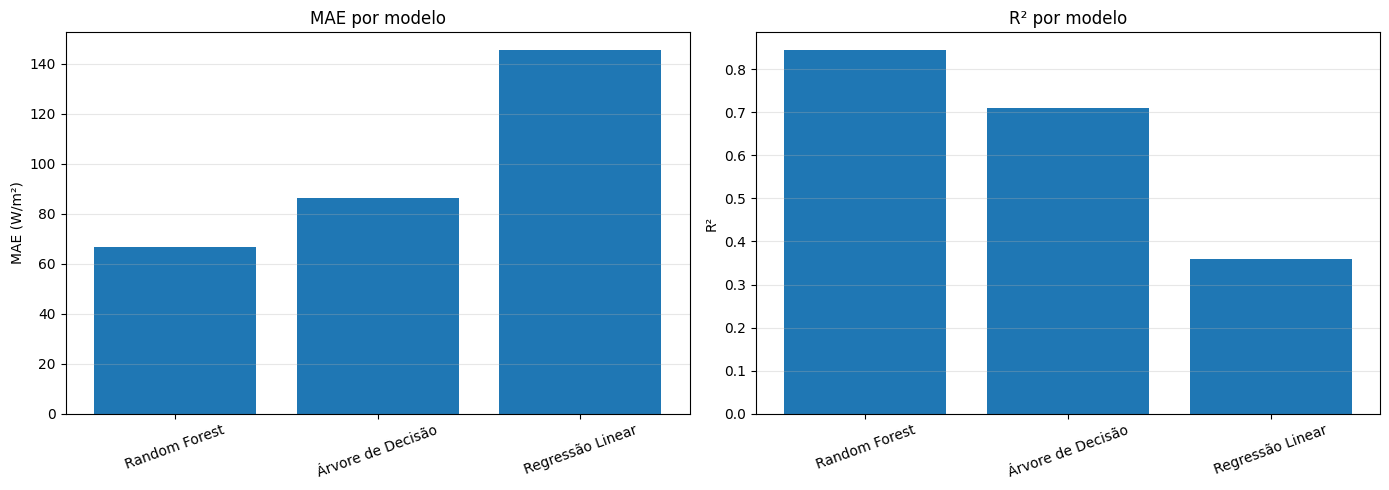

In [11]:
# Comparação visual das métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparacao["Modelo"], comparacao["MAE (W/m²)"])
axes[0].set_title("MAE por modelo")
axes[0].set_ylabel("MAE (W/m²)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(comparacao["Modelo"], comparacao["R²"])
axes[1].set_title("R² por modelo")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Valores reais × previstos

A seguir, o gráfico usa o modelo **Random Forest** como exemplo. A linha de referência representa a situação ideal em que o valor previsto seria exatamente igual ao valor observado.

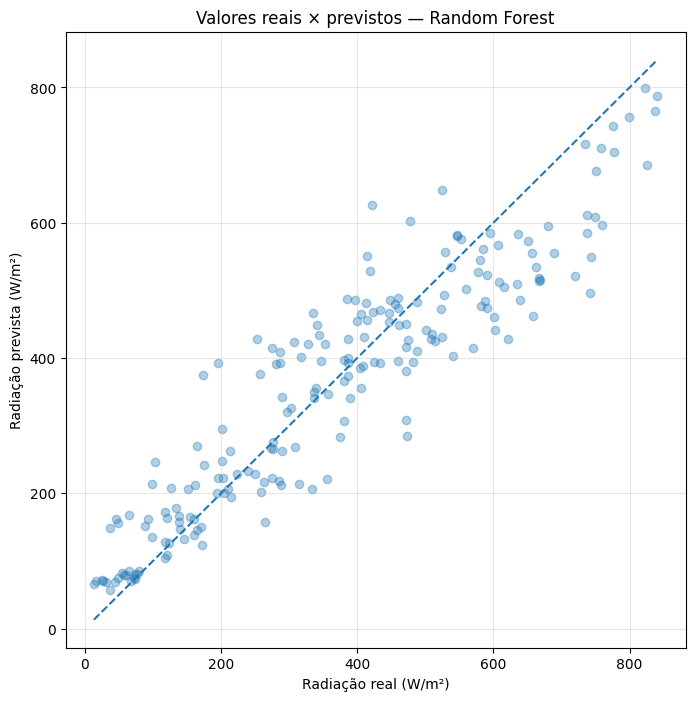

In [12]:
modelo_grafico = "Random Forest"
y_pred_grafico = previsoes[modelo_grafico]

plt.figure(figsize=(8, 8))
plt.scatter(y_teste, y_pred_grafico, alpha=0.35)

limite_min = min(y_teste.min(), y_pred_grafico.min())
limite_max = max(y_teste.max(), y_pred_grafico.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.title(f"Valores reais × previstos — {modelo_grafico}")
plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.grid(alpha=0.3)
plt.show()

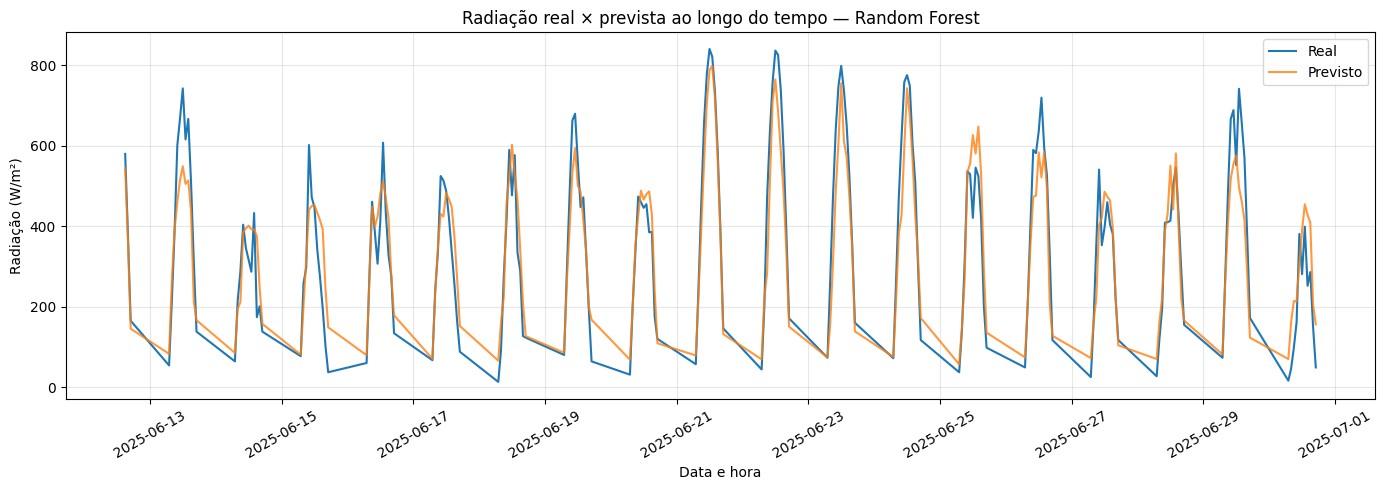

In [13]:
# Evolução temporal: valores reais e previstos no conjunto de teste
plt.figure(figsize=(14, 5))

plt.plot(
    dados["data_hora"].iloc[corte:],
    y_teste.values,
    label="Real"
)

plt.plot(
    dados["data_hora"].iloc[corte:],
    y_pred_grafico,
    label="Previsto",
    alpha=0.8
)

plt.title(f"Radiação real × prevista ao longo do tempo — {modelo_grafico}")
plt.xlabel("Data e hora")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Interpretação dos resultados

Os resultados numéricos da tabela acima são calculados automaticamente quando o notebook é executado, pois os dados são obtidos diretamente da API histórica do Open-Meteo.

A interpretação deve considerar:

- **MAE:** mede o erro médio em termos diretamente interpretáveis de W/m²;
- **MSE:** destaca mais os erros muito grandes;
- **R²:** permite avaliar a proporção da variabilidade da radiação explicada pelo modelo;
- a comparação deve usar o **mesmo conjunto de teste** para os três algoritmos.

### Sobre a hora

A variável `hora` é importante porque a radiação solar possui forte comportamento diário. Portanto, duas condições meteorológicas semelhantes podem estar associadas a níveis diferentes de radiação dependendo do horário.

### Sobre a limitação do modelo

A previsão de `radiacao_w_m2` **não equivale à previsão de energia elétrica produzida por um sistema fotovoltaico**. Para estimar geração seriam necessários outros fatores, como potência instalada, área e características dos módulos, eficiência, orientação e inclinação, perdas do sistema, temperatura dos módulos e demais condições operacionais.

Além disso, os dados do Open-Meteo usados na atividade são históricos estimados por modelos/reanálise; eles não representam necessariamente a leitura de um sensor específico instalado em Petrolina.

## Comparação dos resultados

Os três modelos de regressão apresentaram desempenhos diferentes na previsão da radiação solar: Regressão Linear, Árvore de Decisão e Random Forest. A comparação foi realizada utilizando as métricas MAE, MSE e R² no mesmo conjunto de teste, garantindo uma avaliação equivalente entre os modelos.

A Regressão Linear apresentou um MAE de valor W/m², MSE de valor e R² de valor. Por ser um modelo mais simples, ele serve como uma referência para verificar o quanto modelos capazes de representar relações não lineares conseguem melhorar a previsão.

A **Árvore de Decisão** apresentou MAE de valor W/m², MSE de valor e R² de valor. Esse modelo consegue representar relações não lineares entre as condições meteorológicas e a radiação solar, porém pode apresentar maior variação nas previsões quando comparado a métodos baseados em várias árvores.

Já o Random Forest apresentou MAE de valor W/m², MSE de valor e R² de valor. Por combinar várias árvores de decisão, o algoritmo consegue representar relações mais complexas entre as variáveis de entrada e a radiação solar.

Comparando as métricas, o modelo que apresentou o menor MAE e MSE e o maior R² foi o nome do modelo. Isso indica que, dentro do conjunto de teste utilizado, esse modelo apresentou os menores erros médios e conseguiu explicar uma parcela maior da variação observada na radiação solar.

De maneira geral, os resultados mostram que as condições meteorológicas e principalmente a **hora do dia** possuem relação com a radiação solar. Entretanto, a qualidade das previsões também depende das características dos dados utilizados e do fato de que a radiação fornecida pelo Open-Meteo é baseada em dados históricos de modelos/reanálise, e não necessariamente em medições de um sensor específico. Portanto, os resultados devem ser interpretados como uma estimativa da radiação solar, e não como uma previsão direta da energia elétrica gerada por um sistema fotovoltaico.

## 9. Conclusão

Foram treinados e comparados três algoritmos de regressão — **Regressão Linear, Árvore de Decisão e Random Forest** — utilizando a mesma divisão temporal de treino e teste.

A escolha do modelo para uma aplicação real deve considerar conjuntamente os erros obtidos, a estabilidade das previsões e as características do problema. Neste exercício, a tabela de métricas e os gráficos fornecem a base objetiva para essa comparação.

> **Importante:** execute todas as células em ordem para gerar os valores reais das métricas a partir dos dados da API.

## Conclusão

Neste exercício, foi desenvolvido um modelo de regressão para estimar a radiação solar horizontal média em Petrolina (PE), utilizando dados históricos obtidos pela API Open-Meteo. Foram utilizadas como variáveis de entrada a temperatura, umidade relativa, cobertura de nuvens, velocidade do vento e a hora do dia.

Para realizar a comparação, foram treinados três algoritmos diferentes: Regressão Linear, Árvore de Decisão e Random Forest. Os dados foram divididos respeitando a ordem temporal, utilizando aproximadamente 80% das primeiras observações para treinamento e os 20% finais para teste, evitando o embaralhamento dos registros.

Os modelos foram avaliados utilizando MAE, MSE e R², permitindo analisar tanto o tamanho dos erros quanto a capacidade de explicar a variação da radiação solar. Os resultados mostram que diferentes algoritmos podem apresentar desempenhos distintos dependendo da relação entre as variáveis meteorológicas e a radiação. A variável hora também possui importância relevante, pois a quantidade de radiação solar varia naturalmente ao longo do dia.

Apesar dos resultados obtidos, é importante destacar que a previsão da radiação solar não representa diretamente a quantidade de energia elétrica produzida por um sistema fotovoltaico. Para estimar a geração de energia seriam necessários outros fatores, como potência instalada, eficiência dos painéis, orientação, inclinação e perdas do sistema.

Dessa forma, o exercício permitiu aplicar na prática conceitos de aprendizado de máquina para regressão, desde a obtenção e preparação dos dados até o treinamento, avaliação e comparação de diferentes modelos.